# **Projeto IA Dália  - O Modelo**

## **Informações**

Nos notebooks anteriores, realizamos uma análise exploratória, após a detecção de anomalias, executamos uma etapa para a limpeza da base de dados.

Como última etapa. realizamos uma análise com testes, com o intuito de saber como cada variável e informação influenciava no nosso estudo e como elas se relacionam entre si.

> URL:
>
> https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data

### **Importando Bibliotecas e Materiais**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import boxplot as bp
import pingouin as pg
import itertools
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif

### **Abrindo Dataset**

In [2]:
df = pd.read_csv("../data/processed/maternal_health_clean.csv")

print(df.shape)
df.head()

(451, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


### **Separando Features (X) e Alvo (y)**

> Relembrando: nosso alvo é `RiskLevel`.
>
> - X = informações da gestante.
> - y = risco que queremos prever.

In [3]:
X = df.drop(columns=["RiskLevel"])
y = df["RiskLevel"]

In [4]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

Target:
RiskLevel


### **Análise de Informação das Features**
- Investigando quais variáveis possuem maior relação informacional com a classificação do nível de risco.

In [42]:
mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "Mutual Information": mi
}).sort_values(
    "Mutual Information",
    ascending=False
)

mi_df

,Feature,Mutual Information
3,BS,0.234004
1,SystolicBP,0.232235
0,Age,0.118014
5,HeartRate,0.092250
2,DiastolicBP,0.070753
4,BodyTemp,0.034785


### **Distribuição das Features por Nível de Risco**
- Observando visualmente a separação e a sobreposição entre as classes.

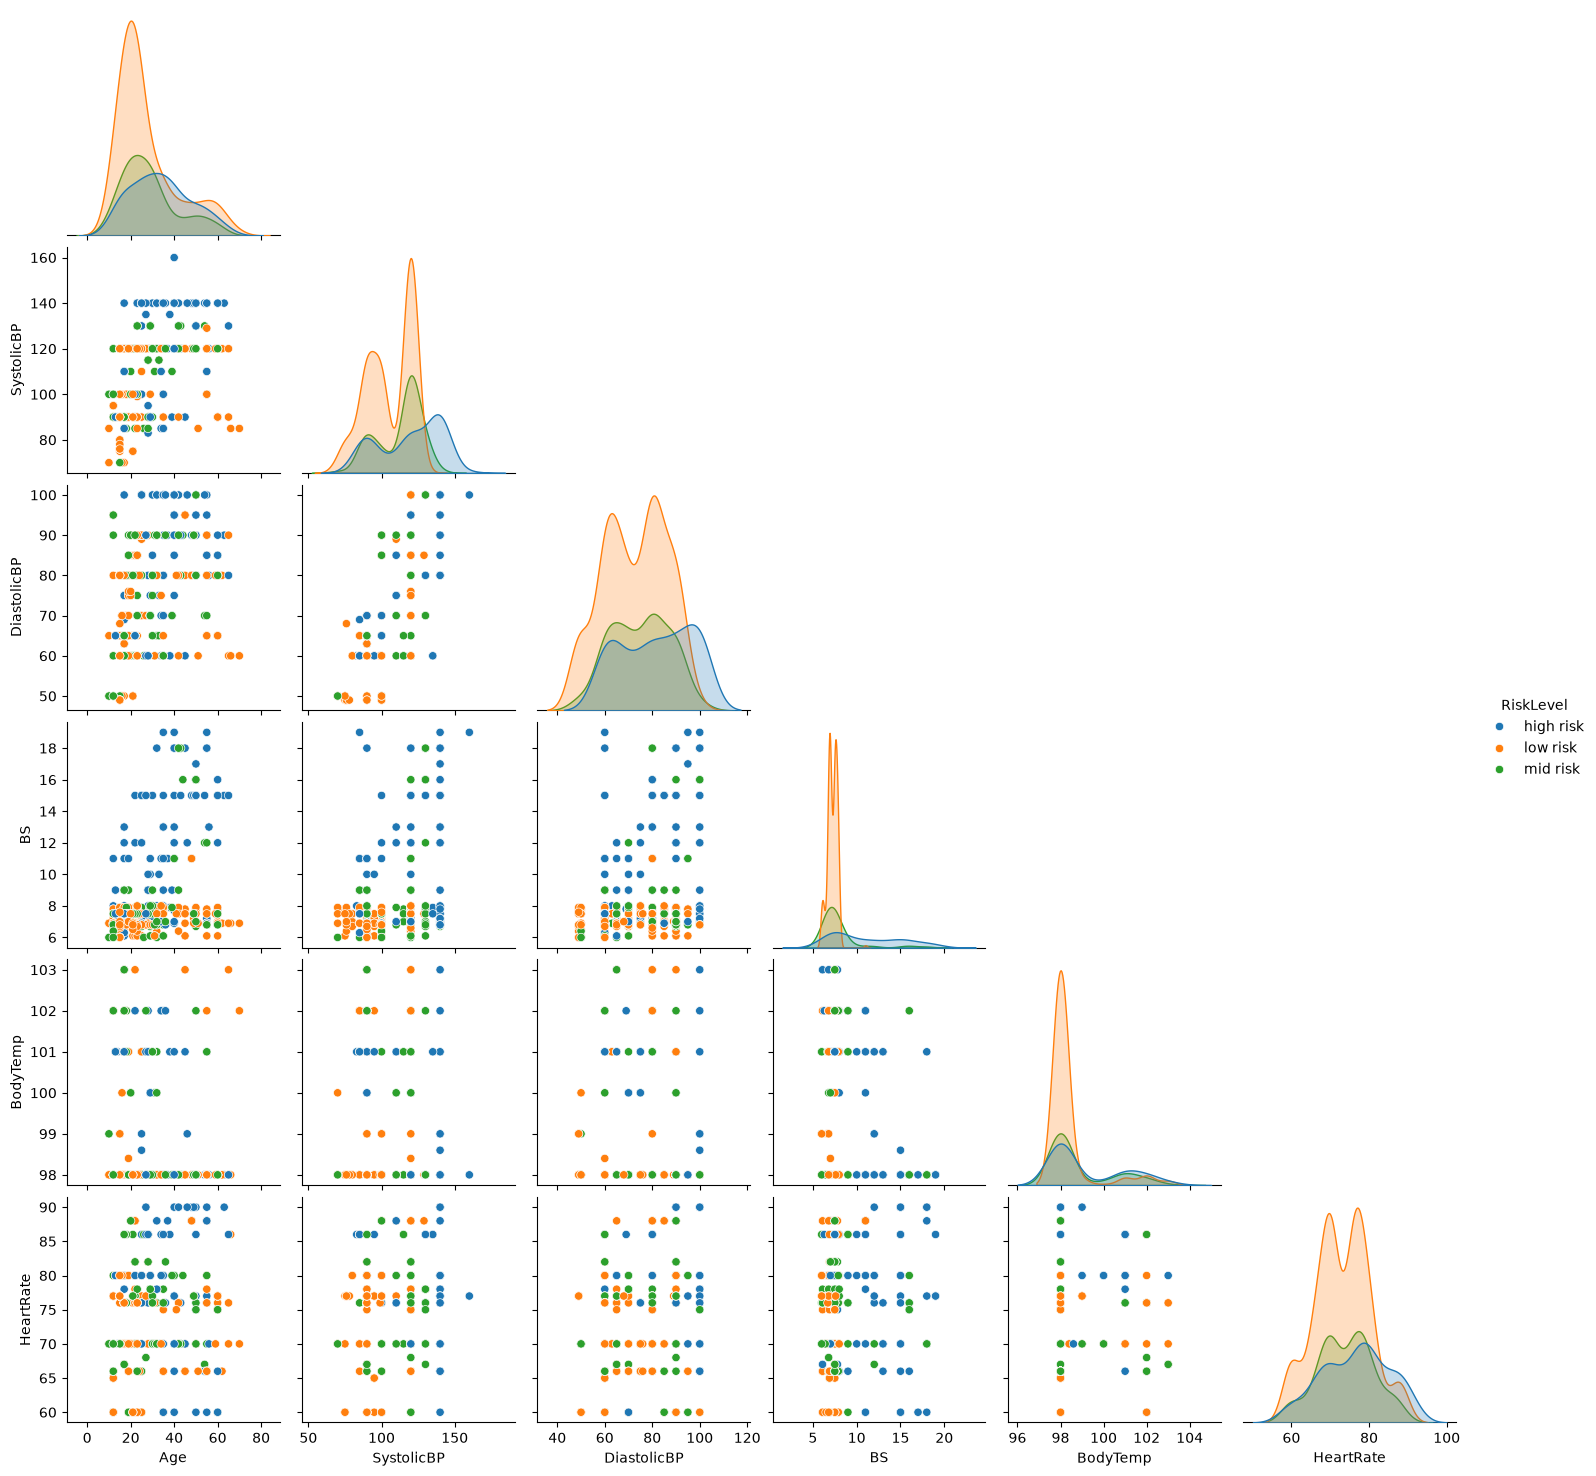

In [43]:
sns.pairplot(
    df,
    vars=[
        "Age",
        "SystolicBP",
        "DiastolicBP",
        "BS",
        "BodyTemp",
        "HeartRate"
    ],
    hue="RiskLevel",
    corner=True
)

plt.show()

### **Separando Treino e Teste**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True) * 100)

Treino: (360, 6)
Teste: (91, 6)

Distribuição no treino:
RiskLevel
low risk     51.666667
high risk    24.722222
mid risk     23.611111
Name: proportion, dtype: float64

Distribuição no teste:
RiskLevel
low risk     51.648352
high risk    25.274725
mid risk     23.076923
Name: proportion, dtype: float64


### **Modelos**

> **Modelos selecionados no treinamento:**
>
> - **Random Forest**
>
> - **Decision Tree**
>
>   Uma árvore única, para termos uma referência mais simples.
>
> - **Logistic Regression**
>
>   Um modelo linear. É ótimo como baseline porque é simples e interpretável.
>
> - **SVM**
>
>   Pode funcionar bem quando as fronteiras entre classes não são simplesmente lineares.
>
> - **KNN**
>
>   Outro modelo simples, baseado na proximidade entre observações.

In [12]:
modelos = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(random_state=42))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}

### **Cross - Validation**

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados = []

for nome, modelo_teste in modelos.items():

    scores_acc = cross_val_score(
        modelo_teste,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    scores_f1 = cross_val_score(
        modelo_teste,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )

    resultados.append({
        "Modelo": nome,
        "Acurácia média": scores_acc.mean(),
        "Acurácia std": scores_acc.std(),
        "F1-macro médio": scores_f1.mean(),
        "F1-macro std": scores_f1.std()
    })

resultados_df = pd.DataFrame(resultados)

resultados_df.sort_values(
    "F1-macro médio",
    ascending=False
)

,Modelo,Acurácia média,Acurácia std,F1-macro médio,F1-macro std
3,SVM,0.705556,0.020412,0.598482,0.017751
1,Decision Tree,0.625000,0.052705,0.589211,0.037446
4,KNN,0.675000,0.068381,0.586998,0.062282
2,Random Forest,0.666667,0.036218,0.582158,0.034689
0,Logistic Regression,0.661111,0.038889,0.530195,0.034218


In [14]:
modelos_teste = {
    "SVM": modelos["SVM"],
    "Decision Tree": modelos["Decision Tree"],
    "Random Forest": modelos["Random Forest"]
}

for nome, modelo_teste in modelos_teste.items():

    modelo_teste.fit(X_train, y_train)

    y_pred = modelo_teste.predict(X_test)

    print("=" * 50)
    print(nome)
    print("=" * 50)

    print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
    print()
    print(classification_report(y_test, y_pred))
    print("Matriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

SVM
Acurácia: 0.6813

              precision    recall  f1-score   support

   high risk       0.75      0.65      0.70        23
    low risk       0.69      0.91      0.79        47
    mid risk       0.44      0.19      0.27        21

    accuracy                           0.68        91
   macro avg       0.63      0.59      0.58        91
weighted avg       0.65      0.68      0.65        91

Matriz de confusão:
[[15  5  3]
 [ 2 43  2]
 [ 3 14  4]]
Decision Tree
Acurácia: 0.5934

              precision    recall  f1-score   support

   high risk       0.80      0.70      0.74        23
    low risk       0.67      0.68      0.67        47
    mid risk       0.26      0.29      0.27        21

    accuracy                           0.59        91
   macro avg       0.58      0.55      0.56        91
weighted avg       0.61      0.59      0.60        91

Matriz de confusão:
[[16  4  3]
 [ 1 32 14]
 [ 3 12  6]]
Random Forest
Acurácia: 0.5934

              precision    recall  f1-

### **Grid Search**

In [15]:
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC())
])

param_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
    "model__kernel": ["rbf", "linear"]
}

grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_svm.best_params_)

print(f"\nMelhor F1-macro:")
print(f"{grid_svm.best_score_:.4f}")

Melhores parâmetros:
{'model__C': 10, 'model__gamma': 0.1, 'model__kernel': 'rbf'}

Melhor F1-macro:
0.6366


In [16]:
svm_otimizado = grid_svm.best_estimator_

y_pred_svm = svm_otimizado.predict(X_test)

print("===== SVM OTIMIZADO =====")

print(f"Acurácia: {accuracy_score(y_test, y_pred_svm):.4f}")

print(f"F1-macro: {f1_score(y_test, y_pred_svm, average='macro'):.4f}")

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_svm))

print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_svm))

===== SVM OTIMIZADO =====
Acurácia: 0.6374
F1-macro: 0.5303

Relatório de classificação:
              precision    recall  f1-score   support

   high risk       0.79      0.65      0.71        23
    low risk       0.64      0.87      0.74        47
    mid risk       0.25      0.10      0.14        21

    accuracy                           0.64        91
   macro avg       0.56      0.54      0.53        91
weighted avg       0.59      0.64      0.59        91

Matriz de confusão:
[[15  6  2]
 [ 2 41  4]
 [ 2 17  2]]


### **Estratégias para Melhorar a Classificação**

#### **Preparando os Dados do Treino:**

In [29]:
y_train_stage1 = y_train.apply(
    lambda x: "high risk" if x == "high risk" else "not high risk"
)

mask_low_mid = y_train.isin(["low risk", "mid risk"])

X_train_stage2 = X_train[mask_low_mid]
y_train_stage2 = y_train[mask_low_mid]

print("Etapa 1:")
print(y_train_stage1.value_counts())

print("\nEtapa 2:")
print(y_train_stage2.value_counts())

Etapa 1:
RiskLevel
not high risk    271
high risk         89
Name: count, dtype: int64

Etapa 2:
RiskLevel
low risk    186
mid risk     85
Name: count, dtype: int64


#### **Classificadores:**

In [30]:
modelo_stage1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1,
        gamma="scale"
    ))
])

modelo_stage2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1,
        gamma="scale"
    ))
])

In [31]:
modelo_stage1.fit(X_train, y_train_stage1)

modelo_stage2.fit(
    X_train_stage2,
    y_train_stage2
)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [33]:
def predicao_hierarquica(X):
    pred_stage1 = modelo_stage1.predict(X)
    
    pred_final = []

    for i, pred in enumerate(pred_stage1):
        if pred == "high risk":
            pred_final.append("high risk")
        else:
            pred_stage2 = modelo_stage2.predict(X.iloc[[i]])[0]
            pred_final.append(pred_stage2)

    return pred_final

In [34]:
y_pred_hierarquico = predicao_hierarquica(X_test)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_hierarquico))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hierarquico))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hierarquico))

Accuracy:
0.6923076923076923

Classification Report:
              precision    recall  f1-score   support

   high risk       0.83      0.65      0.73        23
    low risk       0.69      0.94      0.79        47
    mid risk       0.44      0.19      0.27        21

    accuracy                           0.69        91
   macro avg       0.66      0.59      0.60        91
weighted avg       0.67      0.69      0.66        91


Confusion Matrix:
[[15  5  3]
 [ 1 44  2]
 [ 2 15  4]]


#### **Comparação por Validação Cruzada:**

In [35]:
cv_final = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

modelos_finais = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1,
            gamma="scale"
        ))
    ]),

    "SVM + peso mid": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1,
            gamma="scale",
            class_weight={
                "high risk": 1,
                "low risk": 1,
                "mid risk": 1.5
            }
        ))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])
}

In [36]:
resultados_finais = []

for nome, modelo in modelos_finais.items():

    scores = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=cv_final,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    resultados_finais.append({
        "Modelo": nome,
        "Accuracy média": scores["test_accuracy"].mean(),
        "Accuracy std": scores["test_accuracy"].std(),
        "F1-macro média": scores["test_f1_macro"].mean(),
        "F1-macro std": scores["test_f1_macro"].std()
    })

resultados_finais_df = pd.DataFrame(resultados_finais)

resultados_finais_df.sort_values(
    "F1-macro média",
    ascending=False
)

,Modelo,Accuracy média,Accuracy std,F1-macro média,F1-macro std
1,SVM + peso mid,0.725000,0.026932,0.659292,0.021369
0,SVM,0.705556,0.020412,0.598482,0.017751
3,Decision Tree,0.625000,0.052705,0.589211,0.037446
5,KNN,0.675000,0.068381,0.586998,0.062282
4,Random Forest,0.666667,0.036218,0.582158,0.034689
2,Logistic Regression,0.661111,0.038889,0.530195,0.034218


### **Treinamento do Modelo Final**

In [37]:
modelo_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        class_weight={
            "high risk": 1,
            "low risk": 1,
            "mid risk": 1.5
        }
    ))
])

modelo_final.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [38]:
y_pred_final = modelo_final.predict(X_test)

print("Accuracy:", modelo_final.score(X_test, y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_final, labels=[
    "high risk",
    "low risk",
    "mid risk"
]))

Accuracy: 0.6593406593406593

Classification Report:
              precision    recall  f1-score   support

   high risk       0.75      0.65      0.70        23
    low risk       0.68      0.87      0.77        47
    mid risk       0.36      0.19      0.25        21

    accuracy                           0.66        91
   macro avg       0.60      0.57      0.57        91
weighted avg       0.63      0.66      0.63        91


Matriz de Confusão:
[[15  5  3]
 [ 2 41  4]
 [ 3 14  4]]


#### **Matriz de Confusão:**

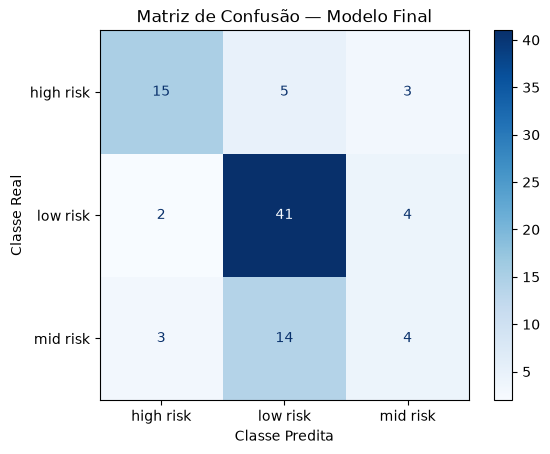

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    labels=["high risk", "low risk", "mid risk"],
    cmap="Blues"
)

plt.title("Matriz de Confusão — Modelo Final")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

#### **Métricas por Classe:**

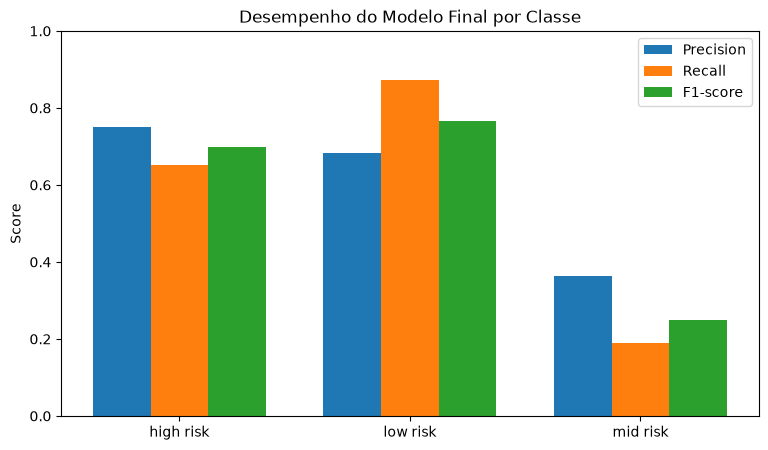

In [41]:
classes = ["high risk", "low risk", "mid risk"]

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred_final,
    labels=classes
)

x = np.arange(len(classes))
largura = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - largura, precision, largura, label="Precision")
plt.bar(x, recall, largura, label="Recall")
plt.bar(x + largura, f1, largura, label="F1-score")

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Desempenho do Modelo Final por Classe")
plt.legend()
plt.show()